<a href="https://colab.research.google.com/github/trang1981/ELAPS/blob/main/Notebooks/Santander_ELAPS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

print(os.listdir("/content"))

if os.path.exists("/content/drive"):
    print("Inside /content/drive:", os.listdir("/content/drive"))

['.config', 'drive', 'sample_data']
Inside /content/drive: ['MyDrive']


In [ ]:
import os

print(os.path.exists("/content/drive/MyDrive"))

True


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive")[:20])

['Santander_External_Validation_Results']


In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive/Santander_External_Validation_Results"):
    for f in files:
        print(os.path.join(root, f))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Kiểm tra thông tin dữ liệu file Santander Product Recommendation

In [ ]:

# ==============================================
# STEP 1. Mount Google Drive
# ==============================================

from google.colab import drive
drive.mount('/content/drive')

# ==============================================
# STEP 2. Tìm file train_ver2.csv
# ==============================================

import os

file_path = None

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "train_ver2.csv" in files:
        file_path = os.path.join(root, "train_ver2.csv")
        break

if file_path is None:
    raise FileNotFoundError("Không tìm thấy train_ver2.csv trong Google Drive!")

print("Đã tìm thấy file:")
print(file_path)

# ==============================================
# STEP 3. Chỉ giữ các cột cần thiết
# ==============================================

keep_columns = [
    "fecha_dato",
    "ncodpers",
    "ind_empleado",
    "pais_residencia",
    "sexo",
    "age",
    "fecha_alta",
    "ind_nuevo",
    "antiguedad",
    "indrel",
    "ult_fec_cli_1t",
    "indrel_1mes",
    "tiprel_1mes",
    "indresi",
    "indext",
    "conyuemp",
    "canal_entrada",
    "indfall",
    "tipodom",
    "cod_prov",
    "nomprov",
    "ind_actividad_cliente",
    "renta",
    "segmento",
    "ind_tjcr_fin_ult1"
]

# ==============================================
# STEP 4. Đọc theo từng chunk
# ==============================================

import pandas as pd

output_file = "/content/drive/MyDrive/Santander_CreditCard.csv"

chunksize = 500000

first_chunk = True
total_rows = 0

for chunk in pd.read_csv(
    file_path,
    usecols=keep_columns,
    chunksize=chunksize,
    low_memory=False
):

    total_rows += len(chunk)

    chunk.to_csv(
        output_file,
        mode='w' if first_chunk else 'a',
        header=first_chunk,
        index=False
    )

    print(f"Đã xử lý {total_rows:,} dòng")

    first_chunk = False

print("="*60)
print("HOÀN THÀNH!")
print("File đã lưu tại:")
print(output_file)

# ==============================================
# STEP 5. Kiểm tra file mới
# ==============================================

df = pd.read_csv(output_file, nrows=5)

print(df.head())

print(df.columns.tolist())

print("Số cột:", len(df.columns))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đã tìm thấy file:
/content/drive/MyDrive/train_ver2.csv
Đã xử lý 500,000 dòng
Đã xử lý 1,000,000 dòng
Đã xử lý 1,500,000 dòng
Đã xử lý 2,000,000 dòng
Đã xử lý 2,500,000 dòng
Đã xử lý 3,000,000 dòng
Đã xử lý 3,500,000 dòng
Đã xử lý 4,000,000 dòng
Đã xử lý 4,500,000 dòng
Đã xử lý 5,000,000 dòng
Đã xử lý 5,500,000 dòng
Đã xử lý 6,000,000 dòng
Đã xử lý 6,500,000 dòng
Đã xử lý 7,000,000 dòng
Đã xử lý 7,500,000 dòng
Đã xử lý 8,000,000 dòng
Đã xử lý 8,500,000 dòng
Đã xử lý 9,000,000 dòng
Đã xử lý 9,500,000 dòng
Đã xử lý 10,000,000 dòng
Đã xử lý 10,500,000 dòng
Đã xử lý 11,000,000 dòng
Đã xử lý 11,500,000 dòng
Đã xử lý 12,000,000 dòng
Đã xử lý 12,500,000 dòng
Đã xử lý 13,000,000 dòng
Đã xử lý 13,500,000 dòng
Đã xử lý 13,647,309 dòng
HOÀN THÀNH!
File đã lưu tại:
/content/drive/MyDrive/Santander_CreditCard.csv
   fecha_dato  ncodpers ind_empleado pais_residencia sexo  

XỬ LÝ LAKELAGE VÀ GỘP DỮ LIỆU

In [ ]:
# ==========================================================
# 1. Mount Google Drive
# ==========================================================

from google.colab import drive
drive.mount('/content/drive')

# ==========================================================
# 2. Tự động tìm file Santander_CreditCard.csv trong Drive
# ==========================================================

import os
import pandas as pd
import numpy as np

input_file = None

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "Santander_CreditCard.csv" in files:
        input_file = os.path.join(root, "Santander_CreditCard.csv")
        break

if input_file is None:
    raise FileNotFoundError("Không tìm thấy file Santander_CreditCard.csv trong Google Drive.")

print("Đang đọc file:")
print(input_file)

# ==========================================================
# 3. Đọc dữ liệu
# ==========================================================

df = pd.read_csv(input_file, low_memory=False)

print("Kích thước dữ liệu gốc:", df.shape)

# ==========================================================
# 4. Chuẩn hóa kiểu dữ liệu
# ==========================================================

df["fecha_dato"] = pd.to_datetime(df["fecha_dato"], errors="coerce")
df["fecha_alta"] = pd.to_datetime(df["fecha_alta"], errors="coerce")

df["ind_tjcr_fin_ult1"] = pd.to_numeric(
    df["ind_tjcr_fin_ult1"],
    errors="coerce"
).fillna(0).astype(int)

# Loại các dòng thiếu ngày quan trọng
df = df.dropna(subset=["fecha_dato", "fecha_alta"])

# ==========================================================
# 5. Chỉ giữ dữ liệu trong năm đầu tiên từ fecha_alta
# ==========================================================

df["end_observation"] = df["fecha_alta"] + pd.DateOffset(years=1)

df = df[
    (df["fecha_dato"] >= df["fecha_alta"]) &
    (df["fecha_dato"] < df["end_observation"])
].copy()

df = df.sort_values(["ncodpers", "fecha_dato"])

print("Sau khi giữ năm đầu tiên:", df.shape)

# ==========================================================
# 6. Hàm lấy giá trị đầu/cuối an toàn
# ==========================================================

def safe_last(g, col):
    if col in g.columns:
        s = g[col].dropna()
        return s.iloc[-1] if len(s) > 0 else np.nan
    return np.nan

def safe_first(g, col):
    if col in g.columns:
        s = g[col].dropna()
        return s.iloc[0] if len(s) > 0 else np.nan
    return np.nan

# ==========================================================
# 7. Xử lý từng khách hàng theo nguyên tắc leakage-aware
# ==========================================================

def process_customer(g):
    g = g.sort_values("fecha_dato").copy()

    # Nếu có mở thẻ trong cửa sổ quan sát
    has_card = (g["ind_tjcr_fin_ult1"] == 1).any()

    if has_card:
        event_date = g.loc[g["ind_tjcr_fin_ult1"] == 1, "fecha_dato"].min()

        # Chỉ giữ dữ liệu trước tháng mở thẻ
        g_before = g[g["fecha_dato"] < event_date].copy()

        # Nếu không có dữ liệu trước event thì loại khách hàng
        if g_before.empty:
            return None

        target = 1

    else:
        # Không mở thẻ: giữ toàn bộ năm đầu tiên
        g_before = g.copy()
        target = 0

    out = {}

    # ID
    out["ncodpers"] = safe_first(g_before, "ncodpers")

    # Không dùng fecha_dato làm feature, chỉ giữ để kiểm tra
    out["last_snapshot_date"] = g_before["fecha_dato"].max()
    out["fecha_alta"] = safe_first(g_before, "fecha_alta")

    # Lấy giá trị cuối trước event
    last_cols = [
        "ind_empleado",
        "pais_residencia",
        "sexo",
        "age",
        "ind_nuevo",
        "antiguedad",
        "indrel",
        "indrel_1mes",
        "tiprel_1mes",
        "indresi",
        "indext",
        "conyuemp",
        "indfall",
        "tipodom",
        "cod_prov",
        "nomprov",
        "ind_actividad_cliente",
        "renta",
        "segmento"
    ]

    for col in last_cols:
        out[col] = safe_last(g_before, col)

    # Lấy giá trị đầu
    out["canal_entrada"] = safe_first(g_before, "canal_entrada")

    # Không giữ ult_fec_cli_1t vì thiếu nhiều
    out["TARGET"] = target

    return pd.Series(out)

# ==========================================================
# 8. Gom về 1 dòng/khách hàng
# ==========================================================

customer_level = (
    df.groupby("ncodpers", group_keys=False)
      .apply(process_customer)
      .reset_index(drop=True)
)

customer_level = customer_level.dropna(how="all").copy()

# ==========================================================
# 9. Kiểm tra dữ liệu sau xử lý
# ==========================================================

print("Kích thước dữ liệu cuối:", customer_level.shape)
print("\nPhân bố TARGET:")
print(customer_level["TARGET"].value_counts())
print("\nTỷ lệ TARGET:")
print(customer_level["TARGET"].value_counts(normalize=True))

print("\nKiểm tra số khách hàng:")
print("Số dòng:", len(customer_level))
print("Số khách hàng duy nhất:", customer_level["ncodpers"].nunique())

# ==========================================================
# 10. Lưu kết quả vào Google Drive
# ==========================================================

output_file = "/content/drive/MyDrive/Santander_CreditCard_LeakageAware_CustomerLevel.csv"

customer_level.to_csv(output_file, index=False)

print("\nĐã lưu file:")
print(output_file)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đang đọc file:
/content/drive/MyDrive/Santander_CreditCard.csv
Kích thước dữ liệu gốc: (13647309, 25)
Sau khi giữ năm đầu tiên: (1865323, 26)


/tmp/ipykernel_6024/3145901736.py:159: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(process_customer)


Kích thước dữ liệu cuối: (255627, 24)

Phân bố TARGET:
TARGET
0.0    254036
1.0      1591
Name: count, dtype: int64

Tỷ lệ TARGET:
TARGET
0.0    0.993776
1.0    0.006224
Name: proportion, dtype: float64

Kiểm tra số khách hàng:
Số dòng: 255627
Số khách hàng duy nhất: 255627

Đã lưu file:
/content/drive/MyDrive/Santander_CreditCard_LeakageAware_CustomerLevel.csv


In [ ]:
# ==========================================================
# 0. Cài thư viện nếu cần
# ==========================================================

!pip install -q imbalanced-learn xgboost shap

# ==========================================================
# 1. Mount Google Drive và đọc dữ liệu
# ==========================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np

file_path = None

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "Santander_CreditCard_LeakageAware_CustomerLevel.csv" in files:
        file_path = os.path.join(root, "Santander_CreditCard_LeakageAware_CustomerLevel.csv")
        break

if file_path is None:
    raise FileNotFoundError("Không tìm thấy file dữ liệu đã xử lý trong Google Drive.")

df = pd.read_csv(file_path, low_memory=False)

print("Loaded file:", file_path)
print("Shape:", df.shape)
print(df.head())

Mounted at /content/drive
Loaded file: /content/drive/MyDrive/Santander_CreditCard_LeakageAware_CustomerLevel.csv
Shape: (255627, 24)
   ncodpers last_snapshot_date  fecha_alta ind_empleado pais_residencia sexo  \
0   15891.0         2015-08-28  2015-07-28            N              ES    H   
1   16063.0         2016-05-28  2015-11-19            N              ES    H   
2   16203.0         2016-05-28  2015-12-23            N              ES    V   
3   16502.0         2016-05-28  2015-09-30            N              ES    H   
4   17457.0         2015-08-28  2014-09-16            N              ES    H   

   age  ind_nuevo  antiguedad  indrel  ... conyuemp indfall tipodom cod_prov  \
0   59        0.0         246    99.0  ...        N       N     1.0     28.0   
1   62        0.0         255     1.0  ...        N       N     1.0     28.0   
2   70        0.0         255     1.0  ...        N       N     1.0      8.0   
3   58        0.0           8     1.0  ...        N       N     1

In [ ]:
# ==========================================================
# 2. Preprocessing summary
# ==========================================================

summary = pd.DataFrame({
    "Item": [
        "Number of customer-level records",
        "Number of unique customers",
        "Number of features before encoding",
        "Positive cases",
        "Negative cases",
        "Positive rate",
        "Missing values"
    ],
    "Value": [
        len(df),
        df["ncodpers"].nunique(),
        df.drop(columns=["TARGET"]).shape[1],
        int((df["TARGET"] == 1).sum()),
        int((df["TARGET"] == 0).sum()),
        round(df["TARGET"].mean(), 4),
        int(df.isna().sum().sum())
    ]
})

print(summary)

                                 Item        Value
0    Number of customer-level records  255627.0000
1          Number of unique customers  255627.0000
2  Number of features before encoding      23.0000
3                      Positive cases    1591.0000
4                      Negative cases  254036.0000
5                       Positive rate       0.0062
6                      Missing values  406065.0000


In [ ]:
# ==========================================================
# 3. Chuẩn bị dữ liệu cho mô hình
# ==========================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, accuracy_score, recall_score,
    precision_score, f1_score, classification_report
)
from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier

# Không dùng ID và các cột ngày làm feature
drop_cols = [
    "TARGET",
    "ncodpers",
    "fecha_alta",
    "last_snapshot_date"
]

drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=drop_cols)
y = df["TARGET"].astype(int)

# Tách numeric / categorical
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

# Chia train/test stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Impute numeric
num_imputer = SimpleImputer(strategy="median")
X_train_num = pd.DataFrame(
    num_imputer.fit_transform(X_train[num_cols]),
    columns=num_cols,
    index=X_train.index
)

X_test_num = pd.DataFrame(
    num_imputer.transform(X_test[num_cols]),
    columns=num_cols,
    index=X_test.index
)

# Impute categorical
cat_imputer = SimpleImputer(strategy="most_frequent")
X_train_cat_raw = pd.DataFrame(
    cat_imputer.fit_transform(X_train[cat_cols]),
    columns=cat_cols,
    index=X_train.index
)

X_test_cat_raw = pd.DataFrame(
    cat_imputer.transform(X_test[cat_cols]),
    columns=cat_cols,
    index=X_test.index
)

# Ordinal encoding
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

X_train_cat = pd.DataFrame(
    encoder.fit_transform(X_train_cat_raw),
    columns=cat_cols,
    index=X_train.index
)

X_test_cat = pd.DataFrame(
    encoder.transform(X_test_cat_raw),
    columns=cat_cols,
    index=X_test.index
)

# Ghép lại
X_train_processed = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_processed = pd.concat([X_test_num, X_test_cat], axis=1)

print("Train shape:", X_train_processed.shape)
print("Test shape:", X_test_processed.shape)
print("Train target distribution:")
print(y_train.value_counts(normalize=True))

Numeric columns: ['age', 'ind_nuevo', 'antiguedad', 'indrel', 'tipodom', 'cod_prov', 'ind_actividad_cliente', 'renta']
Categorical columns: ['ind_empleado', 'pais_residencia', 'sexo', 'indrel_1mes', 'tiprel_1mes', 'indresi', 'indext', 'conyuemp', 'indfall', 'nomprov', 'segmento', 'canal_entrada']
Train shape: (204501, 20)
Test shape: (51126, 20)
Train target distribution:
TARGET
0    0.993775
1    0.006225
Name: proportion, dtype: float64


In [ ]:
# ==========================================================
# 4. Random Oversampling - ROS
# ==========================================================

ros = RandomOverSampler(random_state=42)

X_train_ros, y_train_ros = ros.fit_resample(
    X_train_processed,
    y_train
)

print("Before ROS:")
print(y_train.value_counts())

print("After ROS:")
print(pd.Series(y_train_ros).value_counts())

Before ROS:
TARGET
0    203228
1      1273
Name: count, dtype: int64
After ROS:
TARGET
0    203228
1    203228
Name: count, dtype: int64


In [ ]:
# ==========================================================
# 5. XGBoost + ROS
# ==========================================================

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train_ros, y_train_ros)

y_prob = xgb.predict_proba(X_test_processed)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

auc = roc_auc_score(y_test, y_prob)
acc = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

result = pd.DataFrame({
    "Model": ["XGBoost + ROS"],
    "AUC": [auc],
    "Accuracy": [acc],
    "Recall": [recall],
    "Precision": [precision],
    "F1-score": [f1]
})

print(result)
print(classification_report(y_test, y_pred))

           Model       AUC  Accuracy    Recall  Precision  F1-score
0  XGBoost + ROS  0.963439  0.925341  0.823899   0.065126   0.12071
              precision    recall  f1-score   support

           0       1.00      0.93      0.96     50808
           1       0.07      0.82      0.12       318

    accuracy                           0.93     51126
   macro avg       0.53      0.87      0.54     51126
weighted avg       0.99      0.93      0.96     51126



In [ ]:
# ==========================================================
# 6. Ranking Evaluation: Precision@K, Lift@K
# ==========================================================

ranking = pd.DataFrame({
    "y_true": y_test.values,
    "y_prob": y_prob
})

ranking = ranking.sort_values("y_prob", ascending=False).reset_index(drop=True)

base_rate = ranking["y_true"].mean()

def precision_at_k(df_rank, k_ratio):
    k = int(len(df_rank) * k_ratio)
    top_k = df_rank.iloc[:k]
    precision_k = top_k["y_true"].mean()
    captured = top_k["y_true"].sum()
    capture_rate = captured / df_rank["y_true"].sum()
    lift = precision_k / base_rate
    return precision_k, captured, capture_rate, lift

k_list = [0.10, 0.20, 0.30]

rank_results = []

for k in k_list:
    p_k, captured, capture_rate, lift = precision_at_k(ranking, k)
    rank_results.append({
        "Top K": f"Top {int(k*100)}%",
        "Precision@K": p_k,
        "Captured Positives": int(captured),
        "Capture Rate": capture_rate,
        "Lift@K": lift
    })

rank_table = pd.DataFrame(rank_results)

print(rank_table)

     Top K  Precision@K  Captured Positives  Capture Rate    Lift@K
0  Top 10%     0.055164                 282      0.886792  8.868965
1  Top 20%     0.029927                 306      0.962264  4.811415
2  Top 30%     0.020408                 313      0.984277  3.281094


In [ ]:
# ==========================================================
# 7. Decile Analysis
# ==========================================================

ranking["decile"] = pd.qcut(
    ranking.index + 1,
    q=10,
    labels=[f"D{i}" for i in range(1, 11)]
)

decile_table = ranking.groupby("decile").agg(
    Customers=("y_true", "count"),
    Positives=("y_true", "sum"),
    Adoption_Rate=("y_true", "mean"),
    Avg_Prob=("y_prob", "mean")
).reset_index()

decile_table["Lift"] = decile_table["Adoption_Rate"] / base_rate

print(decile_table)

  decile  Customers  Positives  Adoption_Rate  Avg_Prob      Lift
0     D1       5113        282       0.055154  0.654955  8.867231
1     D2       5113         24       0.004694  0.234361  0.754658
2     D3       5112          7       0.001369  0.061297  0.220152
3     D4       5113          4       0.000782  0.015200  0.125776
4     D5       5112          1       0.000196  0.005298  0.031450
5     D6       5113          0       0.000000  0.002012  0.000000
6     D7       5112          0       0.000000  0.000895  0.000000
7     D8       5113          0       0.000000  0.000551  0.000000
8     D9       5112          0       0.000000  0.000378  0.000000
9    D10       5113          0       0.000000  0.000218  0.000000


/tmp/ipykernel_2091/2719874600.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_table = ranking.groupby("decile").agg(


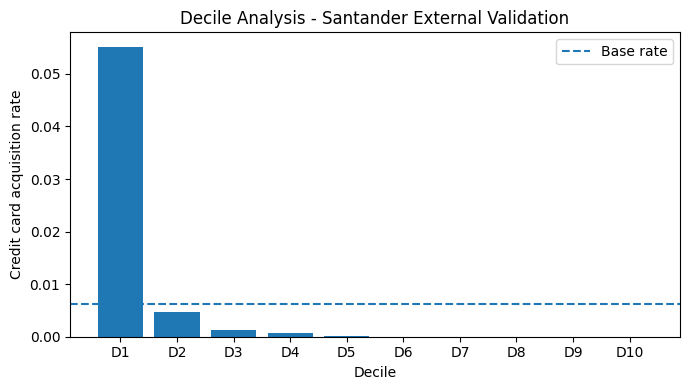

In [ ]:
# ==========================================================
# 8. Vẽ Decile Lift Chart
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.bar(decile_table["decile"], decile_table["Adoption_Rate"])
plt.axhline(base_rate, linestyle="--", label="Base rate")
plt.xlabel("Decile")
plt.ylabel("Credit card acquisition rate")
plt.title("Decile Analysis - Santander External Validation")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
# SHAP SUMMARY PLOT – SANTANDER
# IEEE SINGLE-COLUMN / WORD FRIENDLY
# ==========================================================

import os
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 1. Kiểm tra dữ liệu và lấy mẫu
# ----------------------------------------------------------
sample_size = min(1500, len(X_test_processed))

# Giữ nguyên tên biến nếu dữ liệu là DataFrame
if isinstance(X_test_processed, pd.DataFrame):
    X_shap = X_test_processed.sample(
        n=sample_size,
        random_state=42
    ).copy()
else:
    # Trường hợp X_test_processed là numpy array
    random_generator = np.random.default_rng(42)
    sample_indices = random_generator.choice(
        len(X_test_processed),
        size=sample_size,
        replace=False
    )

    X_shap = X_test_processed[sample_indices]

    # Thay feature_names bằng danh sách tên biến thực tế nếu có
    if "feature_names" in globals():
        X_shap = pd.DataFrame(
            X_shap,
            columns=feature_names
        )
    else:
        X_shap = pd.DataFrame(
            X_shap,
            columns=[
                f"Feature_{i + 1}"
                for i in range(X_shap.shape[1])
            ]
        )

print("Kích thước mẫu SHAP:", X_shap.shape)

# ----------------------------------------------------------
# 2. Tính SHAP values
# ----------------------------------------------------------
explainer = shap.TreeExplainer(xgb)

# Cách mới, tương thích tốt hơn với các phiên bản SHAP mới
try:
    shap_explanation = explainer(X_shap)
    shap_values = shap_explanation.values
except Exception:
    # Dự phòng cho phiên bản SHAP cũ
    shap_values = explainer.shap_values(X_shap)

# Trường hợp mô hình trả về nhiều lớp
if isinstance(shap_values, list):
    # Với bài toán nhị phân, lấy SHAP của lớp dương
    shap_values = shap_values[-1]

# Một số phiên bản SHAP có output dạng:
# (n_samples, n_features, n_classes)
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values = shap_values[:, :, -1]

print("Kích thước SHAP values:", np.asarray(shap_values).shape)

# ----------------------------------------------------------
# 3. Thiết lập font và kích thước IEEE
# ----------------------------------------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Liberation Sans", "DejaVu Sans"],
    "font.size": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 6.5,
    "ytick.labelsize": 6.5,
    "legend.fontsize": 6.5,
    "axes.linewidth": 0.6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

# Xóa figure cũ để tránh chồng hình
plt.close("all")

# ----------------------------------------------------------
# 4. Vẽ SHAP summary plot
# ----------------------------------------------------------
shap.summary_plot(
    shap_values=shap_values,
    features=X_shap,
    feature_names=X_shap.columns.tolist(),
    max_display=10,
    plot_type="dot",
    show=False,
    plot_size=None
)

# ----------------------------------------------------------
# 5. Điều chỉnh kích thước một cột IEEE
# ----------------------------------------------------------
fig = plt.gcf()

# IEEE single-column width khoảng 3.5 inch
# Tăng chiều cao để tên biến và các điểm SHAP không bị dồn
fig.set_size_inches(3.50, 3.05)

axes = fig.get_axes()

# Trục SHAP chính thường là axes[0]
if len(axes) >= 1:
    main_ax = axes[0]

    main_ax.tick_params(
        axis="both",
        which="major",
        labelsize=6.5,
        width=0.6,
        length=2.5
    )

    main_ax.set_xlabel(
        "SHAP value (impact on model output)",
        fontsize=7,
        labelpad=3
    )

    # Không cần nhãn trục y vì tên biến đã hiển thị
    main_ax.set_ylabel("")

    # Điều chỉnh grid nhẹ
    main_ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.35,
        alpha=0.45
    )

    # Đặt font tên biến
    for label in main_ax.get_yticklabels():
        label.set_fontsize(6.5)

# Trục colorbar thường là axes[1]
if len(axes) >= 2:
    colorbar_ax = axes[1]

    colorbar_ax.tick_params(
        labelsize=6,
        width=0.5,
        length=2
    )

    colorbar_ax.set_ylabel(
        "Feature value",
        fontsize=6.5,
        labelpad=2
    )

    # Chỉnh chữ Low và High nếu tồn tại
    for text_item in colorbar_ax.texts:
        text_item.set_fontsize(6)

# ----------------------------------------------------------
# 6. Điều chỉnh lề
# ----------------------------------------------------------
# left tương đối lớn để không cắt tên biến
plt.subplots_adjust(
    left=0.35,
    right=0.88,
    top=0.97,
    bottom=0.16
)

# ----------------------------------------------------------
# 7. Tạo thư mục lưu kết quả
# ----------------------------------------------------------
output_dir = (
    "/content/drive/MyDrive/"
    "Santander_External_Validation_Results"
)

os.makedirs(output_dir, exist_ok=True)

png_path = os.path.join(
    output_dir,
    "SHAP_Summary_Santander_IEEE.png"
)

pdf_path = os.path.join(
    output_dir,
    "SHAP_Summary_Santander_IEEE.pdf"
)

tiff_path = os.path.join(
    output_dir,
    "SHAP_Summary_Santander_IEEE.tiff"
)

# ----------------------------------------------------------
# 8. Lưu hình
# ----------------------------------------------------------
# PNG phù hợp để chèn Word
fig.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.03,
    facecolor="white"
)

# PDF dạng vector, phù hợp bản nộp nếu hệ thống hỗ trợ
fig.savefig(
    pdf_path,
    bbox_inches="tight",
    pad_inches=0.03,
    facecolor="white"
)

# TIFF thường được các tạp chí chấp nhận
fig.savefig(
    tiff_path,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.03,
    facecolor="white",
    pil_kwargs={"compression": "tiff_lzw"}
)

plt.close(fig)

print("\nĐÃ LƯU HÌNH SHAP")
print("PNG :", png_path)
print("PDF :", pdf_path)
print("TIFF:", tiff_path)

Kích thước mẫu SHAP: (1500, 20)
Kích thước SHAP values: (1500, 20)

ĐÃ LƯU HÌNH SHAP
PNG : /content/drive/MyDrive/Santander_External_Validation_Results/SHAP_Summary_Santander_IEEE.png
PDF : /content/drive/MyDrive/Santander_External_Validation_Results/SHAP_Summary_Santander_IEEE.pdf
TIFF: /content/drive/MyDrive/Santander_External_Validation_Results/SHAP_Summary_Santander_IEEE.tiff


✅ Đã tìm thấy file.
Kích thước ảnh : 1768 × 1715 pixels
DPI            : (599.9988, 599.9988)
Định dạng      : PNG


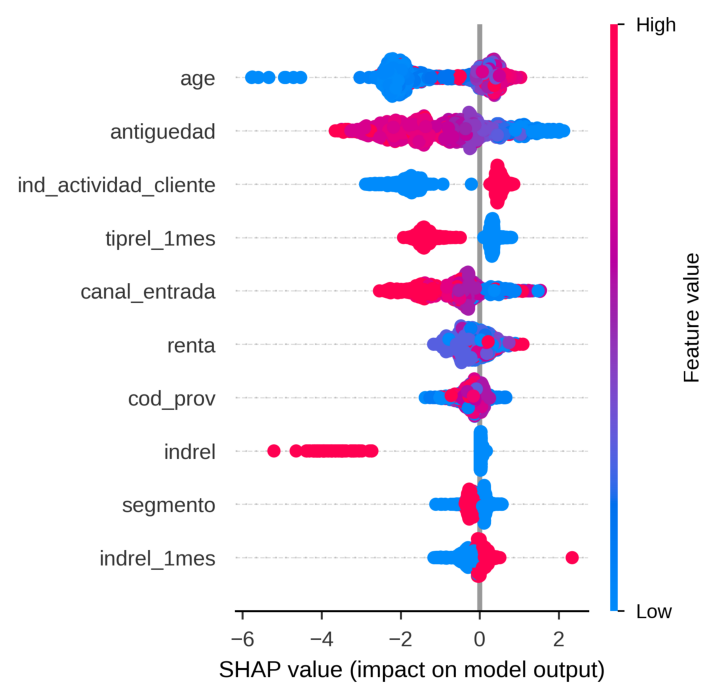

In [ ]:
# ==========================================================
# MỞ VÀ HIỂN THỊ HÌNH SHAP ĐÃ LƯU
# ==========================================================

import os
from PIL import Image
import matplotlib.pyplot as plt

# Đường dẫn tới file PNG
png_path = "/content/drive/MyDrive/Santander_External_Validation_Results/SHAP_Summary_Santander_IEEE.png"

# Kiểm tra file có tồn tại không
if not os.path.exists(png_path):
    print("❌ Không tìm thấy file:")
    print(png_path)
else:
    print("✅ Đã tìm thấy file.")

    # Đọc ảnh
    img = Image.open(png_path)

    # Thông tin ảnh
    print(f"Kích thước ảnh : {img.size[0]} × {img.size[1]} pixels")
    print(f"DPI            : {img.info.get('dpi', 'Không có thông tin DPI')}")
    print(f"Định dạng      : {img.format}")

    # Hiển thị ảnh
    plt.figure(figsize=(8, 7))
    plt.imshow(img)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [ ]:
# ==========================================================
# 10. Bảng top SHAP features
# ==========================================================

mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": X_shap.columns,
    "Mean_ABS_SHAP": mean_abs_shap
}).sort_values("Mean_ABS_SHAP", ascending=False)

print(shap_importance.head(15))

                  Feature  Mean_ABS_SHAP
0                     age       1.250884
2              antiguedad       1.245679
6   ind_actividad_cliente       1.233480
12            tiprel_1mes       0.920344
19          canal_entrada       0.779502
7                   renta       0.339494
5                cod_prov       0.232857
3                  indrel       0.195145
18               segmento       0.194872
11            indrel_1mes       0.193727
17                nomprov       0.178452
10                   sexo       0.142963
1               ind_nuevo       0.091565
14                 indext       0.044603
16                indfall       0.009384


In [ ]:
# ==========================================================
# 11. Lưu kết quả ra Google Drive
# ==========================================================

output_dir = "/content/drive/MyDrive/Santander_External_Validation_Results"
os.makedirs(output_dir, exist_ok=True)

summary.to_csv(os.path.join(output_dir, "preprocessing_summary.csv"), index=False)
result.to_csv(os.path.join(output_dir, "xgboost_ros_results.csv"), index=False)
rank_table.to_csv(os.path.join(output_dir, "precision_lift_at_k.csv"), index=False)
decile_table.to_csv(os.path.join(output_dir, "decile_analysis.csv"), index=False)
shap_importance.to_csv(os.path.join(output_dir, "shap_importance.csv"), index=False)

print("Đã lưu toàn bộ kết quả tại:")
print(output_dir)

Đã lưu toàn bộ kết quả tại:
/content/drive/MyDrive/Santander_External_Validation_Results


In [ ]:
# ==========================================================
# Bootstrap Confidence Interval for AUC
# Santander External Validation
# ==========================================================

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.utils import resample

# ----------------------------------------------------------
# y_test và y_prob phải có sẵn sau khi dự đoán
#
# y_test : nhãn thật
# y_prob : xác suất dự đoán của XGBoost
# ----------------------------------------------------------

# Nếu y_test là Series
y_true = np.array(y_test)

# Xác suất lớp positive
y_score = np.array(y_prob)

# ----------------------------------------------------------
# AUC gốc
# ----------------------------------------------------------

auc = roc_auc_score(y_true, y_score)

print(f"Original AUC = {auc:.6f}")

# ----------------------------------------------------------
# Bootstrap
# ----------------------------------------------------------

n_bootstrap = 1000
rng = np.random.RandomState(42)

bootstrap_scores = []

for i in range(n_bootstrap):

    indices = resample(
        np.arange(len(y_true)),
        replace=True,
        random_state=rng.randint(0, 1000000)
    )

    # Bootstrap sample
    y_boot = y_true[indices]
    score_boot = y_score[indices]

    # Nếu bootstrap chỉ có 1 class thì bỏ qua
    if len(np.unique(y_boot)) < 2:
        continue

    auc_boot = roc_auc_score(y_boot, score_boot)

    bootstrap_scores.append(auc_boot)

bootstrap_scores = np.array(bootstrap_scores)

# ----------------------------------------------------------
# Confidence Interval
# ----------------------------------------------------------

lower = np.percentile(bootstrap_scores, 2.5)
upper = np.percentile(bootstrap_scores, 97.5)

print("="*50)
print(f"AUC                : {auc:.6f}")
print(f"95% Bootstrap CI   : [{lower:.6f}, {upper:.6f}]")
print(f"Bootstrap samples  : {len(bootstrap_scores)}")
print("="*50)

# ----------------------------------------------------------
# Lưu kết quả
# ----------------------------------------------------------

result = pd.DataFrame({
    "Metric": ["AUC"],
    "Value": [auc],
    "CI Lower": [lower],
    "CI Upper": [upper],
    "Bootstrap": [len(bootstrap_scores)]
})

output_dir = "/content/drive/MyDrive/Santander_External_Validation_Results"

result.to_csv(
    f"{output_dir}/Bootstrap_AUC_CI.csv",
    index=False
)

print("Saved to Bootstrap_AUC_CI.csv")

Original AUC = 0.963439
AUC                : 0.963439
95% Bootstrap CI   : [0.955585, 0.970224]
Bootstrap samples  : 1000
Saved to Bootstrap_AUC_CI.csv


In [ ]:
print("xgb:", "xgb" in globals())
print("X_train_processed:", "X_train_processed" in globals())
print("X_test_processed:", "X_test_processed" in globals())
print("y_train:", "y_train" in globals())
print("y_test:", "y_test" in globals())

xgb: False
X_train_processed: True
X_test_processed: True
y_train: True
y_test: True


In [ ]:
# ==========================================================
# Santander External Validation
# AUC Bootstrap CI + Brier Score + Label Shuffling AUC
# ==========================================================

import os
import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.utils import resample, shuffle
from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier

# ----------------------------------------------------------
# Cần có sẵn các biến:
# y_test, y_prob
# X_train_processed, X_test_processed, y_train
# ----------------------------------------------------------

# ==========================================================
# 1. AUC gốc + Brier Score
# ==========================================================

y_true = np.array(y_test)
y_score = np.array(y_prob)

auc = roc_auc_score(y_true, y_score)
brier = brier_score_loss(y_true, y_score)

print(f"Original AUC  = {auc:.6f}")
print(f"Brier Score   = {brier:.6f}")

# ==========================================================
# 2. Bootstrap 95% CI for AUC
# ==========================================================

n_bootstrap = 1000
rng = np.random.RandomState(42)

bootstrap_scores = []

for i in range(n_bootstrap):
    indices = resample(
        np.arange(len(y_true)),
        replace=True,
        random_state=rng.randint(0, 1000000)
    )

    y_boot = y_true[indices]
    score_boot = y_score[indices]

    if len(np.unique(y_boot)) < 2:
        continue

    auc_boot = roc_auc_score(y_boot, score_boot)
    bootstrap_scores.append(auc_boot)

bootstrap_scores = np.array(bootstrap_scores)

lower = np.percentile(bootstrap_scores, 2.5)
upper = np.percentile(bootstrap_scores, 97.5)

print("=" * 50)
print(f"AUC                : {auc:.6f}")
print(f"95% Bootstrap CI   : [{lower:.6f}, {upper:.6f}]")
print(f"Bootstrap samples  : {len(bootstrap_scores)}")
print("=" * 50)

# ==========================================================
# 3. Label Shuffling AUC
# ==========================================================

# Chỉ shuffle nhãn train, không shuffle test
y_train_shuffled = shuffle(
    pd.Series(y_train).reset_index(drop=True),
    random_state=42
)

X_train_shuffle = pd.DataFrame(X_train_processed).reset_index(drop=True)
X_test_shuffle = pd.DataFrame(X_test_processed).reset_index(drop=True)

ros_shuffle = RandomOverSampler(random_state=42)

X_train_shuffle_ros, y_train_shuffle_ros = ros_shuffle.fit_resample(
    X_train_shuffle,
    y_train_shuffled
)

xgb_shuffle = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

xgb_shuffle.fit(X_train_shuffle_ros, y_train_shuffle_ros)

y_prob_shuffle = xgb_shuffle.predict_proba(X_test_shuffle)[:, 1]

label_shuffle_auc = roc_auc_score(y_true, y_prob_shuffle)

print("=" * 50)
print(f"Label Shuffling AUC : {label_shuffle_auc:.6f}")
print("=" * 50)

# ==========================================================
# 4. Lưu kết quả
# ==========================================================

output_dir = "/content/drive/MyDrive/Santander_External_Validation_Results"
os.makedirs(output_dir, exist_ok=True)

result = pd.DataFrame({
    "Metric": [
        "AUC",
        "AUC_CI_Lower",
        "AUC_CI_Upper",
        "Brier_Score",
        "Label_Shuffling_AUC"
    ],
    "Value": [
        auc,
        lower,
        upper,
        brier,
        label_shuffle_auc
    ]
})

output_path = os.path.join(output_dir, "Santander_AUC_Brier_LabelShuffling.csv")

result.to_csv(output_path, index=False)

print("Saved to:", output_path)
print(result)

Original AUC  = 0.963439
Brier Score   = 0.048718
AUC                : 0.963439
95% Bootstrap CI   : [0.955585, 0.970224]
Bootstrap samples  : 1000
Label Shuffling AUC : 0.365920
Saved to: /content/drive/MyDrive/Santander_External_Validation_Results/Santander_AUC_Brier_LabelShuffling.csv
                Metric     Value
0                  AUC  0.963439
1         AUC_CI_Lower  0.955585
2         AUC_CI_Upper  0.970224
3          Brier_Score  0.048718
4  Label_Shuffling_AUC  0.365920


XỨ LÝ PLACEBO VÀ GỘP DỮ LIỆU CHO TẬP DL Santander

In [ ]:
# ==========================================================
# SANTANDER PLACEBO-CUTOFF DATA CONSTRUCTION
# Adopters: retain observed acquisition cutoff
# Non-adopters: receive pseudo-cutoff sampled from adopter-tenure distribution
# ==========================================================

# ==========================================================
# 1. Mount Google Drive
# ==========================================================

from google.colab import drive
drive.mount("/content/drive")

# ==========================================================
# 2. Imports
# ==========================================================

import os
import gc
import numpy as np
import pandas as pd

from scipy.stats import ks_2samp

# ==========================================================
# 3. Configuration
# ==========================================================

INPUT_FILENAME = "Santander_CreditCard.csv"

OUTPUT_DIR = (
    "/content/drive/MyDrive/"
    "Santander_Placebo_Cutoff_Datasets"
)

SEEDS = [42, 52, 62, 72, 82]

os.makedirs(OUTPUT_DIR, exist_ok=True)

# 19 variables taking the last available pre-cutoff value
LAST_VALUE_FEATURES = [
    "ind_empleado",
    "pais_residencia",
    "sexo",
    "age",
    "ind_nuevo",
    "antiguedad",
    "indrel",
    "indrel_1mes",
    "tiprel_1mes",
    "indresi",
    "indext",
    "conyuemp",
    "indfall",
    "tipodom",
    "cod_prov",
    "nomprov",
    "ind_actividad_cliente",
    "renta",
    "segmento",
]

# One variable taking the first available pre-cutoff value
FIRST_VALUE_FEATURES = [
    "canal_entrada",
]

MODEL_FEATURES = LAST_VALUE_FEATURES + FIRST_VALUE_FEATURES

print("Số đặc trưng mô hình:", len(MODEL_FEATURES))

if len(MODEL_FEATURES) != 20:
    raise ValueError(
        f"Danh sách đặc trưng phải có đúng 20 biến, "
        f"nhưng hiện có {len(MODEL_FEATURES)} biến."
    )

# ==========================================================
# 4. Find input file automatically
# ==========================================================

input_file = None

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if INPUT_FILENAME in files:
        input_file = os.path.join(root, INPUT_FILENAME)
        break

if input_file is None:
    raise FileNotFoundError(
        f"Không tìm thấy {INPUT_FILENAME} trong Google Drive."
    )

print("\nĐang đọc file:")
print(input_file)

# ==========================================================
# 5. Load raw data
# ==========================================================

df = pd.read_csv(input_file, low_memory=False)

print("\nKích thước dữ liệu gốc:", df.shape)

required_columns = (
    [
        "ncodpers",
        "fecha_dato",
        "fecha_alta",
        "ind_tjcr_fin_ult1",
    ]
    + MODEL_FEATURES
)

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise KeyError(
        "Dữ liệu thiếu các cột bắt buộc:\n"
        + "\n".join(missing_columns)
    )

# ==========================================================
# 6. Standardize date and target variables
# ==========================================================

df["fecha_dato"] = pd.to_datetime(
    df["fecha_dato"],
    errors="coerce"
)

df["fecha_alta"] = pd.to_datetime(
    df["fecha_alta"],
    errors="coerce"
)

df["ind_tjcr_fin_ult1"] = pd.to_numeric(
    df["ind_tjcr_fin_ult1"],
    errors="coerce"
).fillna(0).astype("int8")

df = df.dropna(
    subset=[
        "ncodpers",
        "fecha_dato",
        "fecha_alta",
    ]
).copy()

# ==========================================================
# 7. Keep only the first relationship year
# ==========================================================

df["end_observation"] = (
    df["fecha_alta"] + pd.DateOffset(years=1)
)

df = df[
    (df["fecha_dato"] >= df["fecha_alta"])
    & (df["fecha_dato"] < df["end_observation"])
].copy()

df = df.sort_values(
    ["ncodpers", "fecha_dato"]
).reset_index(drop=True)

print("Sau khi giữ năm quan hệ đầu tiên:", df.shape)
print("Số khách hàng:", df["ncodpers"].nunique())

# ==========================================================
# 8. Construct customer-level metadata
# ==========================================================

# First credit-card acquisition date within the first year
event_dates = (
    df.loc[
        df["ind_tjcr_fin_ult1"].eq(1),
        ["ncodpers", "fecha_dato"]
    ]
    .groupby("ncodpers")["fecha_dato"]
    .min()
    .rename("event_date")
)

customer_meta = (
    df.groupby("ncodpers", as_index=False)
    .agg(
        fecha_alta=("fecha_alta", "first"),
        first_snapshot=("fecha_dato", "min"),
        last_snapshot=("fecha_dato", "max"),
    )
)

customer_meta = customer_meta.merge(
    event_dates,
    on="ncodpers",
    how="left",
)

customer_meta["TARGET"] = (
    customer_meta["event_date"]
    .notna()
    .astype("int8")
)

# ==========================================================
# 9. Remove invalid adopter cases
# ==========================================================

# An adopter must have at least one snapshot strictly before
# the observed acquisition event.
invalid_adopter = (
    customer_meta["TARGET"].eq(1)
    & (
        customer_meta["first_snapshot"]
        >= customer_meta["event_date"]
    )
)

print(
    "\nAdopters không có dữ liệu trước event:",
    int(invalid_adopter.sum())
)

valid_customer_ids = customer_meta.loc[
    ~invalid_adopter,
    "ncodpers"
]

customer_meta = customer_meta.loc[
    ~invalid_adopter
].copy()

df = df[
    df["ncodpers"].isin(valid_customer_ids)
].copy()

# ==========================================================
# 10. Compute adopter-tenure distribution
# ==========================================================

adopter_mask = customer_meta["TARGET"].eq(1)

customer_meta.loc[
    adopter_mask,
    "observed_tenure_days"
] = (
    customer_meta.loc[adopter_mask, "event_date"]
    - customer_meta.loc[adopter_mask, "fecha_alta"]
).dt.days

adopter_tenures = (
    customer_meta.loc[
        adopter_mask,
        "observed_tenure_days"
    ]
    .dropna()
    .astype(int)
)

# Only strictly positive tenures are admissible
adopter_tenures = adopter_tenures[
    adopter_tenures > 0
].to_numpy()

adopter_tenures.sort()

if len(adopter_tenures) == 0:
    raise ValueError(
        "Không có adopter tenure hợp lệ để tạo pseudo-cutoff."
    )

print("\nPhân phối adopter tenure:")
print(pd.Series(adopter_tenures).describe())

# ==========================================================
# 11. Feasible tenure range for each non-adopter
# ==========================================================

non_adopter_mask = customer_meta["TARGET"].eq(0)

# Minimum tenure required to retain at least the first snapshot.
# Because records are selected with fecha_dato < cutoff,
# cutoff must be later than first_snapshot.
customer_meta.loc[
    non_adopter_mask,
    "min_feasible_tenure"
] = (
    customer_meta.loc[
        non_adopter_mask,
        "first_snapshot"
    ]
    - customer_meta.loc[
        non_adopter_mask,
        "fecha_alta"
    ]
).dt.days + 1

# Maximum tenure allowed by available observation history.
# +1 allows the final available snapshot to be retained because
# feature records must satisfy fecha_dato < pseudo_cutoff.
customer_meta.loc[
    non_adopter_mask,
    "max_feasible_tenure"
] = (
    customer_meta.loc[
        non_adopter_mask,
        "last_snapshot"
    ]
    - customer_meta.loc[
        non_adopter_mask,
        "fecha_alta"
    ]
).dt.days + 1

customer_meta[
    "min_feasible_tenure"
] = customer_meta[
    "min_feasible_tenure"
].fillna(1).astype(int)

customer_meta[
    "max_feasible_tenure"
] = customer_meta[
    "max_feasible_tenure"
].fillna(1).astype(int)

# ==========================================================
# 12. Sample feasible pseudo-tenures efficiently
# ==========================================================

def sample_feasible_placebo_tenures(
    min_tenures,
    max_tenures,
    empirical_tenures,
    seed,
):
    """
    Sample one placebo tenure for each non-adopter from the
    empirical adopter-tenure distribution.

    Sampling is conditional on:
        min_feasible_tenure <= sampled tenure
        <= max_feasible_tenure

    Returns
    -------
    sampled_tenures : np.ndarray
    fallback_flags  : np.ndarray
        1 where no empirical adopter tenure was available within
        the customer's feasible interval and a nearest feasible
        tenure had to be used.
    """

    rng = np.random.default_rng(seed)

    min_tenures = np.asarray(min_tenures, dtype=int)
    max_tenures = np.asarray(max_tenures, dtype=int)

    sampled = np.empty(
        len(min_tenures),
        dtype=int,
    )

    fallback = np.zeros(
        len(min_tenures),
        dtype="int8",
    )

    for i, (lower, upper) in enumerate(
        zip(min_tenures, max_tenures)
    ):
        if upper < lower:
            upper = lower

        # Empirical adopter tenures satisfying feasibility
        left = np.searchsorted(
            empirical_tenures,
            lower,
            side="left",
        )

        right = np.searchsorted(
            empirical_tenures,
            upper,
            side="right",
        )

        if right > left:
            random_index = rng.integers(
                low=left,
                high=right,
            )

            sampled[i] = empirical_tenures[
                random_index
            ]

        else:
            # Rare fallback:
            # choose the closest adopter tenure and clip it to the
            # customer's feasible history.
            insertion_point = np.searchsorted(
                empirical_tenures,
                lower,
                side="left",
            )

            candidate_indices = []

            if insertion_point > 0:
                candidate_indices.append(
                    insertion_point - 1
                )

            if insertion_point < len(
                empirical_tenures
            ):
                candidate_indices.append(
                    insertion_point
                )

            if candidate_indices:
                candidates = empirical_tenures[
                    candidate_indices
                ]

                closest = candidates[
                    np.argmin(
                        np.abs(candidates - lower)
                    )
                ]

                sampled[i] = int(
                    np.clip(
                        closest,
                        lower,
                        upper,
                    )
                )
            else:
                sampled[i] = lower

            fallback[i] = 1

    return sampled, fallback


# ==========================================================
# 13. Reconstruct one placebo dataset
# ==========================================================

def construct_placebo_dataset(
    longitudinal_df,
    meta_df,
    seed,
):
    """
    Adopters:
        cutoff = observed first acquisition date

    Non-adopters:
        cutoff = fecha_alta + sampled placebo tenure

    All 20 features are reconstructed using only observations
    strictly preceding the assigned cutoff.
    """

    meta_seed = meta_df.copy()

    non_mask = meta_seed["TARGET"].eq(0)

    sampled_tenure, fallback_flag = (
        sample_feasible_placebo_tenures(
            min_tenures=meta_seed.loc[
                non_mask,
                "min_feasible_tenure",
            ].to_numpy(),
            max_tenures=meta_seed.loc[
                non_mask,
                "max_feasible_tenure",
            ].to_numpy(),
            empirical_tenures=adopter_tenures,
            seed=seed,
        )
    )

    meta_seed["assigned_tenure_days"] = np.nan
    meta_seed["fallback_sampling"] = 0

    # Adopters retain true tenure and true cutoff
    meta_seed.loc[
        meta_seed["TARGET"].eq(1),
        "assigned_tenure_days",
    ] = meta_seed.loc[
        meta_seed["TARGET"].eq(1),
        "observed_tenure_days",
    ]

    meta_seed.loc[
        meta_seed["TARGET"].eq(1),
        "assigned_cutoff",
    ] = meta_seed.loc[
        meta_seed["TARGET"].eq(1),
        "event_date",
    ]

    # Non-adopters receive pseudo-tenure and pseudo-cutoff
    meta_seed.loc[
        non_mask,
        "assigned_tenure_days",
    ] = sampled_tenure

    meta_seed.loc[
        non_mask,
        "fallback_sampling",
    ] = fallback_flag

    meta_seed.loc[
        non_mask,
        "assigned_cutoff",
    ] = (
        meta_seed.loc[
            non_mask,
            "fecha_alta",
        ]
        + pd.to_timedelta(
            sampled_tenure,
            unit="D",
        )
    )

    meta_seed[
        "assigned_tenure_days"
    ] = meta_seed[
        "assigned_tenure_days"
    ].astype(int)

    # Merge assigned cutoff into longitudinal records
    working = longitudinal_df.merge(
        meta_seed[
            [
                "ncodpers",
                "TARGET",
                "assigned_cutoff",
                "assigned_tenure_days",
                "fallback_sampling",
            ]
        ],
        on="ncodpers",
        how="inner",
        validate="many_to_one",
    )

    # Strictly pre-cutoff records only
    working = working[
        working["fecha_dato"]
        < working["assigned_cutoff"]
    ].copy()

    working = working.sort_values(
        ["ncodpers", "fecha_dato"]
    )

    # ------------------------------------------------------
    # Aggregate the 20 leakage-aware features
    # ------------------------------------------------------

    aggregation_rules = {
        col: "last"
        for col in LAST_VALUE_FEATURES
    }

    aggregation_rules.update({
        col: "first"
        for col in FIRST_VALUE_FEATURES
    })

    customer_level = (
        working
        .groupby(
            "ncodpers",
            as_index=False,
            sort=False,
        )
        .agg(aggregation_rules)
    )

    # Audit variables
    audit_values = (
        working
        .groupby(
            "ncodpers",
            as_index=False,
            sort=False,
        )
        .agg(
            fecha_alta=("fecha_alta", "first"),
            last_snapshot_date=(
                "fecha_dato",
                "max",
            ),
            assigned_cutoff=(
                "assigned_cutoff",
                "first",
            ),
            assigned_tenure_days=(
                "assigned_tenure_days",
                "first",
            ),
            TARGET=("TARGET", "first"),
            fallback_sampling=(
                "fallback_sampling",
                "first",
            ),
        )
    )

    customer_level = audit_values.merge(
        customer_level,
        on="ncodpers",
        how="inner",
        validate="one_to_one",
    )

    # Ensure final column order
    final_columns = (
        [
            "ncodpers",
            "fecha_alta",
            "last_snapshot_date",
            "assigned_cutoff",
            "assigned_tenure_days",
            "fallback_sampling",
        ]
        + MODEL_FEATURES
        + ["TARGET"]
    )

    customer_level = customer_level[
        final_columns
    ]

    return customer_level, meta_seed


# ==========================================================
# 14. Run five placebo seeds
# ==========================================================

summary_rows = []

for seed in SEEDS:
    print("\n" + "=" * 70)
    print(f"Đang tạo placebo dataset với seed = {seed}")
    print("=" * 70)

    placebo_data, cutoff_meta = (
        construct_placebo_dataset(
            longitudinal_df=df,
            meta_df=customer_meta,
            seed=seed,
        )
    )

    output_file = os.path.join(
        OUTPUT_DIR,
        (
            "Santander_Placebo_"
            f"CustomerLevel_seed_{seed}.csv"
        ),
    )

    placebo_data.to_csv(
        output_file,
        index=False,
    )

    # ------------------------------------------------------
    # Audit placebo tenure distribution
    # ------------------------------------------------------

    adopter_assigned = cutoff_meta.loc[
        cutoff_meta["TARGET"].eq(1),
        "assigned_tenure_days",
    ].dropna()

    non_adopter_assigned = cutoff_meta.loc[
        cutoff_meta["TARGET"].eq(0),
        "assigned_tenure_days",
    ].dropna()

    ks_result = ks_2samp(
        adopter_assigned,
        non_adopter_assigned,
    )

    fallback_count = int(
        cutoff_meta.loc[
            cutoff_meta["TARGET"].eq(0),
            "fallback_sampling",
        ].sum()
    )

    positive_rate = placebo_data[
        "TARGET"
    ].mean()

    summary_rows.append({
        "seed": seed,
        "customers": len(placebo_data),
        "positive_customers": int(
            placebo_data["TARGET"].sum()
        ),
        "positive_rate": positive_rate,
        "adopter_tenure_mean": (
            adopter_assigned.mean()
        ),
        "adopter_tenure_median": (
            adopter_assigned.median()
        ),
        "nonadopter_tenure_mean": (
            non_adopter_assigned.mean()
        ),
        "nonadopter_tenure_median": (
            non_adopter_assigned.median()
        ),
        "tenure_KS": ks_result.statistic,
        "tenure_KS_pvalue": ks_result.pvalue,
        "fallback_count": fallback_count,
        "output_file": output_file,
    })

    print("Kích thước:", placebo_data.shape)
    print(
        "Số khách hàng duy nhất:",
        placebo_data["ncodpers"].nunique(),
    )
    print(
        "Phân bố TARGET:\n",
        placebo_data["TARGET"].value_counts(),
    )
    print(
        "Tỷ lệ TARGET:",
        round(positive_rate, 6),
    )
    print(
        "Adopter tenure mean:",
        round(adopter_assigned.mean(), 2),
    )
    print(
        "Non-adopter placebo tenure mean:",
        round(non_adopter_assigned.mean(), 2),
    )
    print(
        "KS giữa hai phân phối tenure:",
        round(ks_result.statistic, 4),
    )
    print(
        "Số trường hợp fallback:",
        fallback_count,
    )
    print("Đã lưu:", output_file)

    del placebo_data
    del cutoff_meta
    gc.collect()

# ==========================================================
# 15. Save audit summary
# ==========================================================

summary_df = pd.DataFrame(summary_rows)

summary_file = os.path.join(
    OUTPUT_DIR,
    "Santander_Placebo_Cutoff_Audit_Summary.csv",
)

summary_df.to_csv(
    summary_file,
    index=False,
)

print("\n" + "=" * 70)
print("HOÀN THÀNH 5 PLACEBO DATASETS")
print("=" * 70)

display(summary_df)

print("\nThư mục đầu ra:")
print(OUTPUT_DIR)

print("\nFile tổng hợp:")
print(summary_file)

Mounted at /content/drive
Số đặc trưng mô hình: 20

Đang đọc file:
/content/drive/MyDrive/Santander_CreditCard.csv

Kích thước dữ liệu gốc: (13647309, 25)
Sau khi giữ năm quan hệ đầu tiên: (1865323, 26)
Số khách hàng: 256342

Adopters không có dữ liệu trước event: 715

Phân phối adopter tenure:
count    1591.000000
mean      178.792583
std        97.665594
min        31.000000
25%        94.000000
50%       165.000000
75%       264.000000
max       364.000000
dtype: float64

Đang tạo placebo dataset với seed = 42
Kích thước: (255627, 27)
Số khách hàng duy nhất: 255627
Phân bố TARGET:
 TARGET
0    254036
1      1591
Name: count, dtype: int64
Tỷ lệ TARGET: 0.006224
Adopter tenure mean: 178.79
Non-adopter placebo tenure mean: 175.42
KS giữa hai phân phối tenure: 0.0462
Số trường hợp fallback: 8598
Đã lưu: /content/drive/MyDrive/Santander_Placebo_Cutoff_Datasets/Santander_Placebo_CustomerLevel_seed_42.csv

Đang tạo placebo dataset với seed = 52
Kích thước: (255627, 27)
Số khách hàng duy nh

,seed,customers,positive_customers,positive_rate,adopter_tenure_mean,adopter_tenure_median,nonadopter_tenure_mean,nonadopter_tenure_median,tenure_KS,tenure_KS_pvalue,fallback_count,output_file
0,42,255627,1591,0.006224,178.792583,165.0,175.419063,165.0,0.046168,0.002289,8598,/content/drive/MyDrive/Santander_Placebo_Cutof...
1,52,255627,1591,0.006224,178.792583,165.0,175.353544,165.0,0.046215,0.002258,8598,/content/drive/MyDrive/Santander_Placebo_Cutof...
2,62,255627,1591,0.006224,178.792583,165.0,175.147420,164.0,0.047154,0.001710,8598,/content/drive/MyDrive/Santander_Placebo_Cutof...
3,72,255627,1591,0.006224,178.792583,165.0,175.295923,165.0,0.046560,0.002040,8598,/content/drive/MyDrive/Santander_Placebo_Cutof...
4,82,255627,1591,0.006224,178.792583,165.0,175.146578,165.0,0.046384,0.002148,8598,/content/drive/MyDrive/Santander_Placebo_Cutof...



Thư mục đầu ra:
/content/drive/MyDrive/Santander_Placebo_Cutoff_Datasets

File tổng hợp:
/content/drive/MyDrive/Santander_Placebo_Cutoff_Datasets/Santander_Placebo_Cutoff_Audit_Summary.csv


Fairness

In [ ]:
# ============================================================
# SANTANDER ELAPS
# XGBOOST + RANDOM OVERSAMPLING + FAIRNESS AUDIT
# ============================================================

# Nếu Colab chưa có thư viện, bỏ dấu # ở dòng dưới:
# !pip install -q xgboost imbalanced-learn openpyxl

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    classification_report,
    confusion_matrix,
    brier_score_loss,
    roc_curve
)

from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier


# ============================================================
# 1. KẾT NỐI GOOGLE DRIVE VÀ ĐỌC FILE
# ============================================================

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    print("Google Drive đã được mount hoặc không chạy trên Colab.")

output_file = (
    "/content/drive/MyDrive/"
    "Santander_CreditCard_LeakageAware_CustomerLevel.csv"
)

if not os.path.exists(output_file):
    raise FileNotFoundError(
        f"Không tìm thấy file:\n{output_file}"
    )

df = pd.read_csv(
    output_file,
    low_memory=False
)

print("=" * 100)
print("SANTANDER CREDIT-CARD LEAKAGE-AWARE DATASET")
print("=" * 100)

print("File:", output_file)
print("Dataset shape:", df.shape)

print("\nColumns:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i:02d}. {col}")

print("\nFirst five rows:")
display(df.head())


# ============================================================
# 2. CHUẨN HÓA TÊN CỘT
# ============================================================

df.columns = [
    str(col).strip()
    for col in df.columns
]


def find_column(dataframe, candidates, required=True):
    """
    Tìm cột theo danh sách tên ứng viên,
    không phân biệt chữ hoa/chữ thường.
    """

    lower_map = {
        str(col).strip().lower(): col
        for col in dataframe.columns
    }

    for candidate in candidates:
        key = candidate.strip().lower()

        if key in lower_map:
            return lower_map[key]

    if required:
        raise ValueError(
            "Không tìm thấy cột phù hợp.\n"
            f"Các tên đã thử: {candidates}\n"
            f"Các cột hiện có: {dataframe.columns.tolist()}"
        )

    return None


# ============================================================
# 3. TỰ NHẬN DIỆN CỘT
# ============================================================

TARGET_COL = find_column(
    df,
    [
        "TARGET",
        "TARGET_90D",
        "TARGET_60D",
        "TARGET_180D",
        "target",
        "label",
        "y"
    ],
    required=True
)

SEX_COL = find_column(
    df,
    [
        "sexo",
        "SEX",
        "sex",
        "gender",
        "CLIENT_SEX"
    ],
    required=True
)

AGE_COL = find_column(
    df,
    [
        "age",
        "AGE",
        "age_years",
        "AGE_YEARS"
    ],
    required=True
)

ID_COL = find_column(
    df,
    [
        "ncodpers",
        "CUSTOMER_NUMBER",
        "customer_id",
        "CUSTOMER_ID",
        "id"
    ],
    required=False
)

FECHA_ALTA_COL = find_column(
    df,
    [
        "fecha_alta",
        "FECHA_ALTA"
    ],
    required=False
)

LAST_SNAPSHOT_COL = find_column(
    df,
    [
        "last_snapshot_date",
        "LAST_SNAPSHOT_DATE",
        "snapshot_date"
    ],
    required=False
)

print("\n" + "=" * 100)
print("DETECTED COLUMNS")
print("=" * 100)

print("Target column :", TARGET_COL)
print("Sex column    :", SEX_COL)
print("Age column    :", AGE_COL)
print("ID column     :", ID_COL)
print("Start date    :", FECHA_ALTA_COL)
print("Snapshot date :", LAST_SNAPSHOT_COL)


# ============================================================
# 4. CẤU HÌNH THÍ NGHIỆM
# ============================================================

TEST_SIZE = 0.20
RANDOM_STATE = 42

THRESHOLD = 0.50
TOP_RATE = 0.20

# Santander Product Recommendation:
# H = Female, V = Male.
#
# Code cũng hỗ trợ các giá trị M/F, Male/Female.
SEX_MAP = {
    "H": "Female",
    "V": "Male",
    "M": "Male",
    "F": "Female",
    "MALE": "Male",
    "FEMALE": "Female",
    "NAM": "Male",
    "NU": "Female",
    "NỮ": "Female"
}


# ============================================================
# 5. LÀM SẠCH TARGET
# ============================================================

df_model = df.copy()

df_model[TARGET_COL] = pd.to_numeric(
    df_model[TARGET_COL],
    errors="coerce"
)

before_drop = len(df_model)

df_model = df_model.dropna(
    subset=[TARGET_COL]
).copy()

print(
    "\nRows removed due to missing target:",
    before_drop - len(df_model)
)

unique_target_values = sorted(
    df_model[TARGET_COL].dropna().unique()
)

print("Original target values:", unique_target_values)

# Trường hợp target là boolean
if df_model[TARGET_COL].dtype == bool:
    df_model[TARGET_COL] = (
        df_model[TARGET_COL]
        .astype(int)
    )

# Chỉ giữ target 0/1
df_model = df_model[
    df_model[TARGET_COL].isin([0, 1])
].copy()

df_model[TARGET_COL] = (
    df_model[TARGET_COL]
    .astype(int)
)

if df_model[TARGET_COL].nunique() != 2:
    raise ValueError(
        "Target sau khi làm sạch không có đủ hai lớp 0 và 1."
    )

print("\nTarget distribution:")
print(df_model[TARGET_COL].value_counts())

print(
    "\nPositive rate:",
    f"{df_model[TARGET_COL].mean():.6f}",
    f"({df_model[TARGET_COL].mean() * 100:.4f}%)"
)


# ============================================================
# 6. CHUẨN HÓA TUỔI
# ============================================================

df_model[AGE_COL] = pd.to_numeric(
    df_model[AGE_COL],
    errors="coerce"
)

# Loại các tuổi phi thực tế chỉ khỏi fairness;
# giá trị này vẫn sẽ được impute trong quá trình huấn luyện.
invalid_age_mask = (
    (df_model[AGE_COL] < 0)
    | (df_model[AGE_COL] > 120)
)

df_model.loc[
    invalid_age_mask,
    AGE_COL
] = np.nan

print("\nAge summary:")
print(df_model[AGE_COL].describe())


# ============================================================
# 7. CHUẨN BỊ FEATURE MATRIX
# ============================================================

drop_cols = [TARGET_COL]

for col in [
    ID_COL,
    FECHA_ALTA_COL,
    LAST_SNAPSHOT_COL
]:
    if col is not None:
        drop_cols.append(col)

drop_cols = list(dict.fromkeys(drop_cols))

X = df_model.drop(
    columns=drop_cols,
    errors="ignore"
).copy()

y = df_model[TARGET_COL].copy()

print("\nDropped columns:")
print(drop_cols)

print(
    "\nInitial number of model features:",
    X.shape[1]
)


# ============================================================
# 8. LOẠI CÁC CỘT KHÔNG PHÙ HỢP
# ============================================================

# Loại các cột có toàn bộ giá trị thiếu
all_missing_cols = [
    col for col in X.columns
    if X[col].isna().all()
]

if all_missing_cols:
    print("\nAll-missing columns removed:")
    print(all_missing_cols)

    X = X.drop(
        columns=all_missing_cols
    )

# Loại các cột chỉ có một giá trị duy nhất
constant_cols = [
    col for col in X.columns
    if X[col].nunique(dropna=False) <= 1
]

if constant_cols:
    print("\nConstant columns removed:")
    print(constant_cols)

    X = X.drop(
        columns=constant_cols
    )

# Chuyển datetime sang chuỗi trước khi xác định loại
datetime_cols = (
    X.select_dtypes(
        include=["datetime", "datetimetz"]
    )
    .columns
    .tolist()
)

if datetime_cols:
    print("\nDatetime columns removed:")
    print(datetime_cols)

    X = X.drop(
        columns=datetime_cols
    )


# ============================================================
# 9. CHIA TRAIN / TEST
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("\n" + "=" * 100)
print("TRAIN / TEST SPLIT")
print("=" * 100)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts())

print("\nTest target distribution:")
print(y_test.value_counts())

print(
    "\nTrain positive rate:",
    f"{y_train.mean():.6f}"
)

print(
    "Test positive rate :",
    f"{y_test.mean():.6f}"
)


# ============================================================
# 10. XÁC ĐỊNH NUMERIC VÀ CATEGORICAL
# ============================================================

numeric_cols = (
    X_train.select_dtypes(
        include=[np.number]
    )
    .columns
    .tolist()
)

categorical_cols = [
    col for col in X_train.columns
    if col not in numeric_cols
]

print("\nNumeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)


# ============================================================
# 11. XỬ LÝ NUMERIC
# ============================================================

if numeric_cols:

    numeric_imputer = SimpleImputer(
        strategy="median"
    )

    X_train_numeric = pd.DataFrame(
        numeric_imputer.fit_transform(
            X_train[numeric_cols]
        ),
        columns=numeric_cols,
        index=X_train.index
    )

    X_test_numeric = pd.DataFrame(
        numeric_imputer.transform(
            X_test[numeric_cols]
        ),
        columns=numeric_cols,
        index=X_test.index
    )

else:

    numeric_imputer = None

    X_train_numeric = pd.DataFrame(
        index=X_train.index
    )

    X_test_numeric = pd.DataFrame(
        index=X_test.index
    )


# ============================================================
# 12. XỬ LÝ CATEGORICAL
# ============================================================

if categorical_cols:

    # Chuyển về chuỗi để tránh lỗi mixed type
    X_train_cat_raw = (
        X_train[categorical_cols]
        .copy()
        .astype("object")
    )

    X_test_cat_raw = (
        X_test[categorical_cols]
        .copy()
        .astype("object")
    )

    categorical_imputer = SimpleImputer(
        strategy="most_frequent"
    )

    X_train_cat_imputed = pd.DataFrame(
        categorical_imputer.fit_transform(
            X_train_cat_raw
        ),
        columns=categorical_cols,
        index=X_train.index
    )

    X_test_cat_imputed = pd.DataFrame(
        categorical_imputer.transform(
            X_test_cat_raw
        ),
        columns=categorical_cols,
        index=X_test.index
    )

    # Đảm bảo toàn bộ là string
    X_train_cat_imputed = (
        X_train_cat_imputed.astype(str)
    )

    X_test_cat_imputed = (
        X_test_cat_imputed.astype(str)
    )

    encoder = OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )

    X_train_categorical = pd.DataFrame(
        encoder.fit_transform(
            X_train_cat_imputed
        ),
        columns=categorical_cols,
        index=X_train.index
    )

    X_test_categorical = pd.DataFrame(
        encoder.transform(
            X_test_cat_imputed
        ),
        columns=categorical_cols,
        index=X_test.index
    )

else:

    categorical_imputer = None
    encoder = None

    X_train_categorical = pd.DataFrame(
        index=X_train.index
    )

    X_test_categorical = pd.DataFrame(
        index=X_test.index
    )


# ============================================================
# 13. GHÉP DỮ LIỆU ĐÃ TIỀN XỬ LÝ
# ============================================================

X_train_processed = pd.concat(
    [
        X_train_numeric,
        X_train_categorical
    ],
    axis=1
)

X_test_processed = pd.concat(
    [
        X_test_numeric,
        X_test_categorical
    ],
    axis=1
)

X_test_processed = X_test_processed[
    X_train_processed.columns
]

X_train_processed = (
    X_train_processed
    .astype(float)
)

X_test_processed = (
    X_test_processed
    .astype(float)
)

print("\n" + "=" * 100)
print("PROCESSED DATA")
print("=" * 100)

print(
    "Processed train shape:",
    X_train_processed.shape
)

print(
    "Processed test shape :",
    X_test_processed.shape
)

print(
    "Missing values in train:",
    int(X_train_processed.isna().sum().sum())
)

print(
    "Missing values in test :",
    int(X_test_processed.isna().sum().sum())
)


# ============================================================
# 14. RANDOM OVERSAMPLING
# ============================================================

ros = RandomOverSampler(
    random_state=RANDOM_STATE
)

X_train_ros, y_train_ros = ros.fit_resample(
    X_train_processed,
    y_train
)

print("\n" + "=" * 100)
print("RANDOM OVERSAMPLING")
print("=" * 100)

print("Before ROS:")
print(y_train.value_counts())

print("\nAfter ROS:")
print(pd.Series(y_train_ros).value_counts())

print(
    "\nROS train shape:",
    X_train_ros.shape
)


# ============================================================
# 15. HUẤN LUYỆN XGBOOST
# ============================================================

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train_ros,
    y_train_ros
)


# ============================================================
# 16. DỰ ĐOÁN TRÊN HOLDOUT TEST
# ============================================================

y_prob = model.predict_proba(
    X_test_processed
)[:, 1]

y_pred = (
    y_prob >= THRESHOLD
).astype(int)


# ============================================================
# 17. HIỆU SUẤT MÔ HÌNH
# ============================================================

auc = roc_auc_score(
    y_test,
    y_prob
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

brier = brier_score_loss(
    y_test,
    y_prob
)

fpr_values, tpr_values, _ = roc_curve(
    y_test,
    y_prob
)

ks = np.max(
    tpr_values - fpr_values
)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1]
).ravel()

print("\n" + "=" * 100)
print("SANTANDER ELAPS — XGBOOST + ROS PERFORMANCE")
print("=" * 100)

print(f"AUC       : {auc:.6f}")
print(f"KS        : {ks:.6f}")
print(f"Accuracy  : {accuracy:.6f}")
print(f"Recall    : {recall:.6f}")
print(f"Precision : {precision:.6f}")
print(f"F1-score  : {f1:.6f}")
print(f"Brier     : {brier:.6f}")

print("\nConfusion matrix:")
print(f"TN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TP: {tp}")

print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_pred,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 18. RANKING METRICS
# ============================================================

def calculate_ranking_metrics(
    y_true,
    probabilities,
    top_rates=(0.10, 0.20, 0.30)
):

    ranking_df = pd.DataFrame({
        "TARGET": np.asarray(y_true),
        "PROBABILITY": np.asarray(probabilities)
    })

    ranking_df = ranking_df.sort_values(
        "PROBABILITY",
        ascending=False
    ).reset_index(drop=True)

    total_customers = len(ranking_df)
    total_positives = ranking_df["TARGET"].sum()
    base_rate = ranking_df["TARGET"].mean()

    rows = []

    for rate in top_rates:

        top_n = max(
            1,
            int(np.ceil(total_customers * rate))
        )

        top_df = ranking_df.iloc[:top_n]

        captured = int(
            top_df["TARGET"].sum()
        )

        top_precision = (
            captured / top_n
        )

        capture_rate = (
            captured / total_positives
            if total_positives > 0
            else np.nan
        )

        lift = (
            top_precision / base_rate
            if base_rate > 0
            else np.nan
        )

        rows.append({
            "TOP_K": f"Top {int(rate * 100)}%",
            "TOP_RATE": rate,
            "CUSTOMERS": top_n,
            "PRECISION": top_precision,
            "LIFT": lift,
            "CAPTURED_POSITIVES": captured,
            "CAPTURE_RATE": capture_rate
        })

    return pd.DataFrame(rows)


ranking_metrics = calculate_ranking_metrics(
    y_true=y_test,
    probabilities=y_prob,
    top_rates=(0.10, 0.20, 0.30)
)

print("\n" + "=" * 100)
print("RANKING METRICS")
print("=" * 100)

print(
    ranking_metrics.to_string(
        index=False,
        formatters={
            "TOP_RATE": lambda x: f"{x:.1f}",
            "PRECISION": lambda x: f"{x:.6f}",
            "LIFT": lambda x: f"{x:.6f}",
            "CAPTURE_RATE": lambda x: f"{x:.6f}"
        }
    )
)


# ============================================================
# 19. TẠO FAIRNESS TEST DATAFRAME
# ============================================================

fairness_test = pd.DataFrame(
    index=X_test.index
)

fairness_test[TARGET_COL] = (
    y_test.loc[X_test.index]
    .astype(int)
)

fairness_test["y_prob"] = y_prob
fairness_test["y_pred"] = y_pred

# Các biến nhạy cảm phải lấy từ dữ liệu gốc
fairness_test[SEX_COL] = (
    df_model.loc[X_test.index, SEX_COL]
)

fairness_test[AGE_COL] = pd.to_numeric(
    df_model.loc[X_test.index, AGE_COL],
    errors="coerce"
)

print("\n" + "=" * 100)
print("RAW FAIRNESS VARIABLES")
print("=" * 100)

print("\nRaw sex values:")
print(
    fairness_test[SEX_COL]
    .value_counts(dropna=False)
)

print("\nAge summary:")
print(
    fairness_test[AGE_COL]
    .describe()
)


# ============================================================
# 20. CHUẨN HÓA GIỚI TÍNH
# ============================================================

def standardize_sex(value):

    if pd.isna(value):
        return np.nan

    normalized = (
        str(value)
        .strip()
        .upper()
    )

    return SEX_MAP.get(
        normalized,
        np.nan
    )


fairness_test["SEX_GROUP"] = (
    fairness_test[SEX_COL]
    .apply(standardize_sex)
)

print("\nStandardized sex groups:")
print(
    fairness_test["SEX_GROUP"]
    .value_counts(dropna=False)
)


# ============================================================
# 21. TẠO NHÓM TUỔI
# ============================================================

fairness_test["AGE_GROUP"] = pd.cut(
    fairness_test[AGE_COL],
    bins=[
        -np.inf,
        29,
        45,
        np.inf
    ],
    labels=[
        "Age <30",
        "Age 30–45",
        "Age ≥46"
    ],
    right=True
)

print("\nAge groups:")
print(
    fairness_test["AGE_GROUP"]
    .value_counts(dropna=False)
)


# ============================================================
# 22. HÀM TÍNH FAIRNESS METRICS
# ============================================================

def calculate_group_metrics(
    data,
    group_col,
    group_order,
    target_col,
    probability_col,
    threshold=0.50,
    top_rate=0.20
):

    result_rows = []

    for group_name in group_order:

        group_data = data[
            data[group_col].astype(str)
            == str(group_name)
        ].copy()

        group_data = group_data.dropna(
            subset=[
                target_col,
                probability_col
            ]
        )

        n = len(group_data)

        if n == 0:
            continue

        y_true_group = (
            group_data[target_col]
            .astype(int)
            .to_numpy()
        )

        y_prob_group = (
            group_data[probability_col]
            .astype(float)
            .to_numpy()
        )

        y_pred_group = (
            y_prob_group >= threshold
        ).astype(int)

        base_rate = (
            y_true_group.mean()
        )

        if len(np.unique(y_true_group)) == 2:
            group_auc = roc_auc_score(
                y_true_group,
                y_prob_group
            )
        else:
            group_auc = np.nan

        group_brier = brier_score_loss(
            y_true_group,
            y_prob_group
        )

        group_tn, group_fp, group_fn, group_tp = (
            confusion_matrix(
                y_true_group,
                y_pred_group,
                labels=[0, 1]
            ).ravel()
        )

        if group_tp + group_fn > 0:
            tpr_threshold = (
                group_tp
                / (group_tp + group_fn)
            )
        else:
            tpr_threshold = np.nan

        selection_rate = (
            y_pred_group.mean()
        )

        top_n = max(
            1,
            int(np.ceil(n * top_rate))
        )

        top_group = group_data.nlargest(
            top_n,
            probability_col
        )

        total_positives = (
            group_data[target_col]
            .sum()
        )

        captured_positives = (
            top_group[target_col]
            .sum()
        )

        if total_positives > 0:
            tpr_top_k = (
                captured_positives
                / total_positives
            )
        else:
            tpr_top_k = np.nan

        result_rows.append({
            "Group": group_name,
            "n": n,
            "Base rate": base_rate,
            "AUC": group_auc,
            "Brier": group_brier,
            "TPR@threshold": tpr_threshold,
            "Selection rate@threshold": selection_rate,
            "TPR@top-20%": tpr_top_k
        })

    return pd.DataFrame(result_rows)


# ============================================================
# 23. FAIRNESS THEO GIỚI TÍNH
# ============================================================

sex_metrics = calculate_group_metrics(
    data=fairness_test.dropna(
        subset=["SEX_GROUP"]
    ),
    group_col="SEX_GROUP",
    group_order=[
        "Male",
        "Female"
    ],
    target_col=TARGET_COL,
    probability_col="y_prob",
    threshold=THRESHOLD,
    top_rate=TOP_RATE
)


# ============================================================
# 24. FAIRNESS THEO TUỔI
# ============================================================

age_metrics = calculate_group_metrics(
    data=fairness_test.dropna(
        subset=["AGE_GROUP"]
    ),
    group_col="AGE_GROUP",
    group_order=[
        "Age <30",
        "Age 30–45",
        "Age ≥46"
    ],
    target_col=TARGET_COL,
    probability_col="y_prob",
    threshold=THRESHOLD,
    top_rate=TOP_RATE
)

fairness_metrics = pd.concat(
    [
        sex_metrics,
        age_metrics
    ],
    ignore_index=True
)


# ============================================================
# 25. FAIRNESS SUMMARY
# ============================================================

def calculate_fairness_summary(
    group_metrics,
    dimension
):

    selection_rates = (
        group_metrics[
            "Selection rate@threshold"
        ]
        .dropna()
    )

    tpr_values = (
        group_metrics[
            "TPR@threshold"
        ]
        .dropna()
    )

    auc_values = (
        group_metrics[
            "AUC"
        ]
        .dropna()
    )

    if (
        len(selection_rates) >= 2
        and selection_rates.max() > 0
    ):
        disparate_impact = (
            selection_rates.min()
            / selection_rates.max()
        )
    else:
        disparate_impact = np.nan

    if len(tpr_values) >= 2:
        tpr_gap = (
            tpr_values.max()
            - tpr_values.min()
        )
    else:
        tpr_gap = np.nan

    if len(auc_values) >= 2:
        auc_gap = (
            auc_values.max()
            - auc_values.min()
        )
    else:
        auc_gap = np.nan

    return {
        "Audit dimension": dimension,
        "Disparate impact": disparate_impact,
        "TPR gap": tpr_gap,
        "AUC gap": auc_gap
    }


fairness_summary = pd.DataFrame([
    calculate_fairness_summary(
        sex_metrics,
        "Sex"
    ),
    calculate_fairness_summary(
        age_metrics,
        "Age"
    )
])


# ============================================================
# 26. IN BẢNG FAIRNESS
# ============================================================

print("\n" + "=" * 120)
print("FAIRNESS METRICS BY SEX AND AGE — SANTANDER ELAPS")
print("=" * 120)

print(
    fairness_metrics.to_string(
        index=False,
        formatters={
            "n":
                lambda x: f"{int(x)}",

            "Base rate":
                lambda x: f"{x:.3f}",

            "AUC":
                lambda x: (
                    f"{x:.3f}"
                    if pd.notna(x)
                    else "NA"
                ),

            "Brier":
                lambda x: (
                    f"{x:.3f}"
                    if pd.notna(x)
                    else "NA"
                ),

            "TPR@threshold":
                lambda x: (
                    f"{x:.3f}"
                    if pd.notna(x)
                    else "NA"
                ),

            "Selection rate@threshold":
                lambda x: (
                    f"{x:.3f}"
                    if pd.notna(x)
                    else "NA"
                ),

            "TPR@top-20%":
                lambda x: (
                    f"{x:.3f}"
                    if pd.notna(x)
                    else "NA"
                )
        }
    )
)

print("\n" + "=" * 80)
print("FAIRNESS SUMMARY")
print("=" * 80)

print(
    fairness_summary.to_string(
        index=False,
        formatters={
            "Disparate impact":
                lambda x: (
                    f"{x:.3f}"
                    if pd.notna(x)
                    else "NA"
                ),

            "TPR gap":
                lambda x: (
                    f"{x:.3f}"
                    if pd.notna(x)
                    else "NA"
                ),

            "AUC gap":
                lambda x: (
                    f"{x:.3f}"
                    if pd.notna(x)
                    else "NA"
                )
        }
    )
)


# ============================================================
# 27. TẠO PERFORMANCE TABLE
# ============================================================

performance_table = pd.DataFrame({
    "Metric": [
        "AUC",
        "KS statistic",
        "Accuracy",
        "Recall",
        "Precision",
        "F1-score",
        "Brier score",
        "TN",
        "FP",
        "FN",
        "TP"
    ],
    "Value": [
        auc,
        ks,
        accuracy,
        recall,
        precision,
        f1,
        brier,
        tn,
        fp,
        fn,
        tp
    ]
})


# ============================================================
# 28. LƯU KẾT QUẢ
# ============================================================

save_dir = "/content/drive/MyDrive"

performance_csv = os.path.join(
    save_dir,
    "santander_elaps_performance.csv"
)

ranking_csv = os.path.join(
    save_dir,
    "santander_elaps_ranking_metrics.csv"
)

fairness_csv = os.path.join(
    save_dir,
    "santander_elaps_group_fairness_metrics.csv"
)

summary_csv = os.path.join(
    save_dir,
    "santander_elaps_fairness_summary.csv"
)

prediction_csv = os.path.join(
    save_dir,
    "santander_elaps_test_predictions.csv"
)

excel_file = os.path.join(
    save_dir,
    "santander_elaps_results.xlsx"
)

performance_table.to_csv(
    performance_csv,
    index=False,
    encoding="utf-8-sig"
)

ranking_metrics.to_csv(
    ranking_csv,
    index=False,
    encoding="utf-8-sig"
)

fairness_metrics.to_csv(
    fairness_csv,
    index=False,
    encoding="utf-8-sig"
)

fairness_summary.to_csv(
    summary_csv,
    index=False,
    encoding="utf-8-sig"
)

fairness_test.to_csv(
    prediction_csv,
    index=False,
    encoding="utf-8-sig"
)

with pd.ExcelWriter(
    excel_file,
    engine="openpyxl"
) as writer:

    performance_table.to_excel(
        writer,
        sheet_name="Performance",
        index=False
    )

    ranking_metrics.to_excel(
        writer,
        sheet_name="Ranking metrics",
        index=False
    )

    fairness_metrics.to_excel(
        writer,
        sheet_name="Group fairness",
        index=False
    )

    fairness_summary.to_excel(
        writer,
        sheet_name="Fairness summary",
        index=False
    )

    fairness_test.to_excel(
        writer,
        sheet_name="Test predictions",
        index=False
    )

print("\n" + "=" * 100)
print("FILES SAVED TO GOOGLE DRIVE")
print("=" * 100)

print(performance_csv)
print(ranking_csv)
print(fairness_csv)
print(summary_csv)
print(prediction_csv)
print(excel_file)

Mounted at /content/drive
SANTANDER CREDIT-CARD LEAKAGE-AWARE DATASET
File: /content/drive/MyDrive/Santander_CreditCard_LeakageAware_CustomerLevel.csv
Dataset shape: (255627, 24)

Columns:
01. ncodpers
02. last_snapshot_date
03. fecha_alta
04. ind_empleado
05. pais_residencia
06. sexo
07. age
08. ind_nuevo
09. antiguedad
10. indrel
11. indrel_1mes
12. tiprel_1mes
13. indresi
14. indext
15. conyuemp
16. indfall
17. tipodom
18. cod_prov
19. nomprov
20. ind_actividad_cliente
21. renta
22. segmento
23. canal_entrada
24. TARGET

First five rows:


,ncodpers,last_snapshot_date,fecha_alta,ind_empleado,pais_residencia,sexo,age,ind_nuevo,antiguedad,indrel,...,conyuemp,indfall,tipodom,cod_prov,nomprov,ind_actividad_cliente,renta,segmento,canal_entrada,TARGET
0,15891.0,2015-08-28,2015-07-28,N,ES,H,59,0.0,246,99.0,...,N,N,1.0,28.0,MADRID,0.0,NaN,02 - PARTICULARES,KAT,0.0
1,16063.0,2016-05-28,2015-11-19,N,ES,H,62,0.0,255,1.0,...,N,N,1.0,28.0,MADRID,0.0,NaN,02 - PARTICULARES,KAT,0.0
2,16203.0,2016-05-28,2015-12-23,N,ES,V,70,0.0,255,1.0,...,N,N,1.0,8.0,BARCELONA,1.0,NaN,01 - TOP,KAT,0.0
3,16502.0,2016-05-28,2015-09-30,N,ES,H,58,0.0,8,1.0,...,N,N,1.0,28.0,MADRID,1.0,NaN,02 - PARTICULARES,KHN,0.0
4,17457.0,2015-08-28,2014-09-16,N,ES,H,53,0.0,197,1.0,...,NaN,N,1.0,28.0,MADRID,1.0,102405.75,02 - PARTICULARES,KAT,0.0



DETECTED COLUMNS
Target column : TARGET
Sex column    : sexo
Age column    : age
ID column     : ncodpers
Start date    : fecha_alta
Snapshot date : last_snapshot_date

Rows removed due to missing target: 0
Original target values: [np.float64(0.0), np.float64(1.0)]

Target distribution:
TARGET
0    254036
1      1591
Name: count, dtype: int64

Positive rate: 0.006224 (0.6224%)

Age summary:
count    255627.000000
mean         30.251574
std          12.999447
min           2.000000
25%          21.000000
50%          24.000000
75%          36.000000
max         103.000000
Name: age, dtype: float64

Dropped columns:
['TARGET', 'ncodpers', 'fecha_alta', 'last_snapshot_date']

Initial number of model features: 20

Constant columns removed:
['ind_empleado', 'tipodom']

TRAIN / TEST SPLIT
Train shape: (204501, 18)
Test shape : (51126, 18)

Train target distribution:
TARGET
0    203228
1      1273
Name: count, dtype: int64

Test target distribution:
TARGET
0    50808
1      318
Name: count, 